In [2]:
import math
import sys
from pathlib import Path

_here = Path().resolve()
for _p in [_here, *_here.parents]:
    _src = _p / "src"
    if (_src / "qudits_on_qubits" / "__init__.py").is_file():
        repo_root = _p
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break
else:
    raise ImportError(
        "qudits_on_qubits repo root not found; run the notebook from notebooks/ or the repo root"
    )

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Session, Batch

from qudits_on_qubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt

In [3]:
from qudits_on_qubits.bell_measurements.sampler_circuits import build_sampler_circuits_from_graph, build_sampler_circuits_for_candidate
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet
from iqm.iqm_client import CircuitCompilationOptions, DDMode, STANDARD_DD_STRATEGY, DDStrategy
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm.iqm_naive_move_pass import transpile_to_IQM
from iqm.iqm_client.transpile import ExistingMoveHandlingOptions

from qudits_on_qubits.bell_measurements.sampler_circuits import run_sampler_circuits_to_counts_by_setting
from qudits_on_qubits.bell_measurements.sampler_circuits import decoding_kwargs_from_metadata
from qudits_on_qubits.bell_measurements.postprocessing import compute_bell_value_from_counts

In [4]:
dd_options = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=STANDARD_DD_STRATEGY,
  )

dd_default = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED)

dd_xy4 = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=DDStrategy(
          gate_sequences=[(5, "YXYX", "asap")]
      ),
  )

dd_xy8 = CircuitCompilationOptions(dd_mode=DDMode.ENABLED, 
                                   dd_strategy=DDStrategy(
                                       gate_sequences=[(9, 'XYXYYXYX', 'center')]))

In [50]:
import os
from dotenv import load_dotenv

In [49]:
print(repr(os.getenv("IQM_TOKEN")))

None


In [52]:
load_dotenv()
os.getenv("IQM_TOKEN")

'XWRe8qkpImpdy7m53a8M5ramhDLQNjt+QhAD5pqlousBn1vCVBt4MraM9X0SJzmJ'

In [54]:
provider_garnet = IQMProvider("https://resonance.iqm.tech/", quantum_computer="garnet")
backend_garnet = provider_garnet.get_backend(use_metrics=True)

In [5]:
from provider import get_backend, get_backend_error_profile, generate_random_error_profile, to_static_architecture
from iqm.qiskit_iqm.fake_backends.iqm_fake_backend import IQMFakeBackend
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet

In [6]:
backend = get_backend(quantum_computer="garnet")
error_profile = generate_random_error_profile(backend=backend)

garnet = IQMFakeGarnet()
garnet_architecture = garnet.architecture

static_garnet_architecture = to_static_architecture(garnet_architecture)

static_garnet_architecture = to_static_architecture(garnet_architecture)

garnet_noisy_backend = IQMFakeBackend(architecture=static_garnet_architecture, error_profile=error_profile)

Backend connected successfully, using garnet

Noise profile: random-noise-profile

T1 / T2 / readout
qubit   T1 [us]   T2 [us]  readout 0->1  readout 1->0  readout avg error  readout asymmetry
  QB1 28.050439 25.245395      0.056195      0.060234           0.058214           0.004039
  QB2 49.524858 44.572372      0.045748      0.041239           0.043493          -0.004509
  QB3 72.603312 11.260935      0.056950      0.057219           0.057085           0.000269
  QB4 42.661948 38.395753      0.032013      0.036259           0.034136           0.004246
  QB5 68.270944 13.849672      0.011309      0.020089           0.015699           0.008780
  QB6 35.638083 32.074275      0.013692      0.015915           0.014803           0.002224
  QB7 37.864240 28.150457      0.018190      0.022020           0.020105           0.003830
  QB8 26.265453 23.638907      0.006164      0.015852           0.011008           0.009689
  QB9 77.905544 24.009318      0.020622      0.020153           0.02038

In [62]:
selected_candidate = "monomial_full__sup012_P021_ph012"
#QuditsOnQubits\artifacts\iqm_runs\selected_best\two_qutrit\stage2_top10_rerun20_20260706\exact\rank01_monomial_full__sup023_P012_ph022
artifact_circuit_dir = repo_root / "artifacts" / "iqm_runs" / "raw" / "quantum_circuits" / "garnet" / "ghz3_qpy13" / selected_candidate
legacy_circuit_dir = repo_root.parent / "QuditsOnQubits" / "basis_direct_encoding_benchmarks" / "quantum_circuits" / "ghz3_qpy13" / selected_candidate

for circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
    if (circuit_dir / "graph_state_direct_basis.qpy").is_file():
        break
else:
    raise FileNotFoundError(
        "Circuit artifacts not found. Checked:\n"
        f"- {artifact_circuit_dir}\n"
        f"- {legacy_circuit_dir}"
    )

print(f"Loading circuits from: {circuit_dir}")

with (circuit_dir / "graph_state_direct_basis.qpy").open("rb") as f:
    testqc = qpy.load(f)[0]

with (circuit_dir / "graph_state_direct_basis_transpiled.qpy").open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with (circuit_dir / "F3_W.qpy").open("rb") as f:
    F3sup = qpy.load(f)[0]

Esup = np.load(circuit_dir / "E.npy")

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\garnet\ghz3_qpy13\monomial_full__sup012_P021_ph012


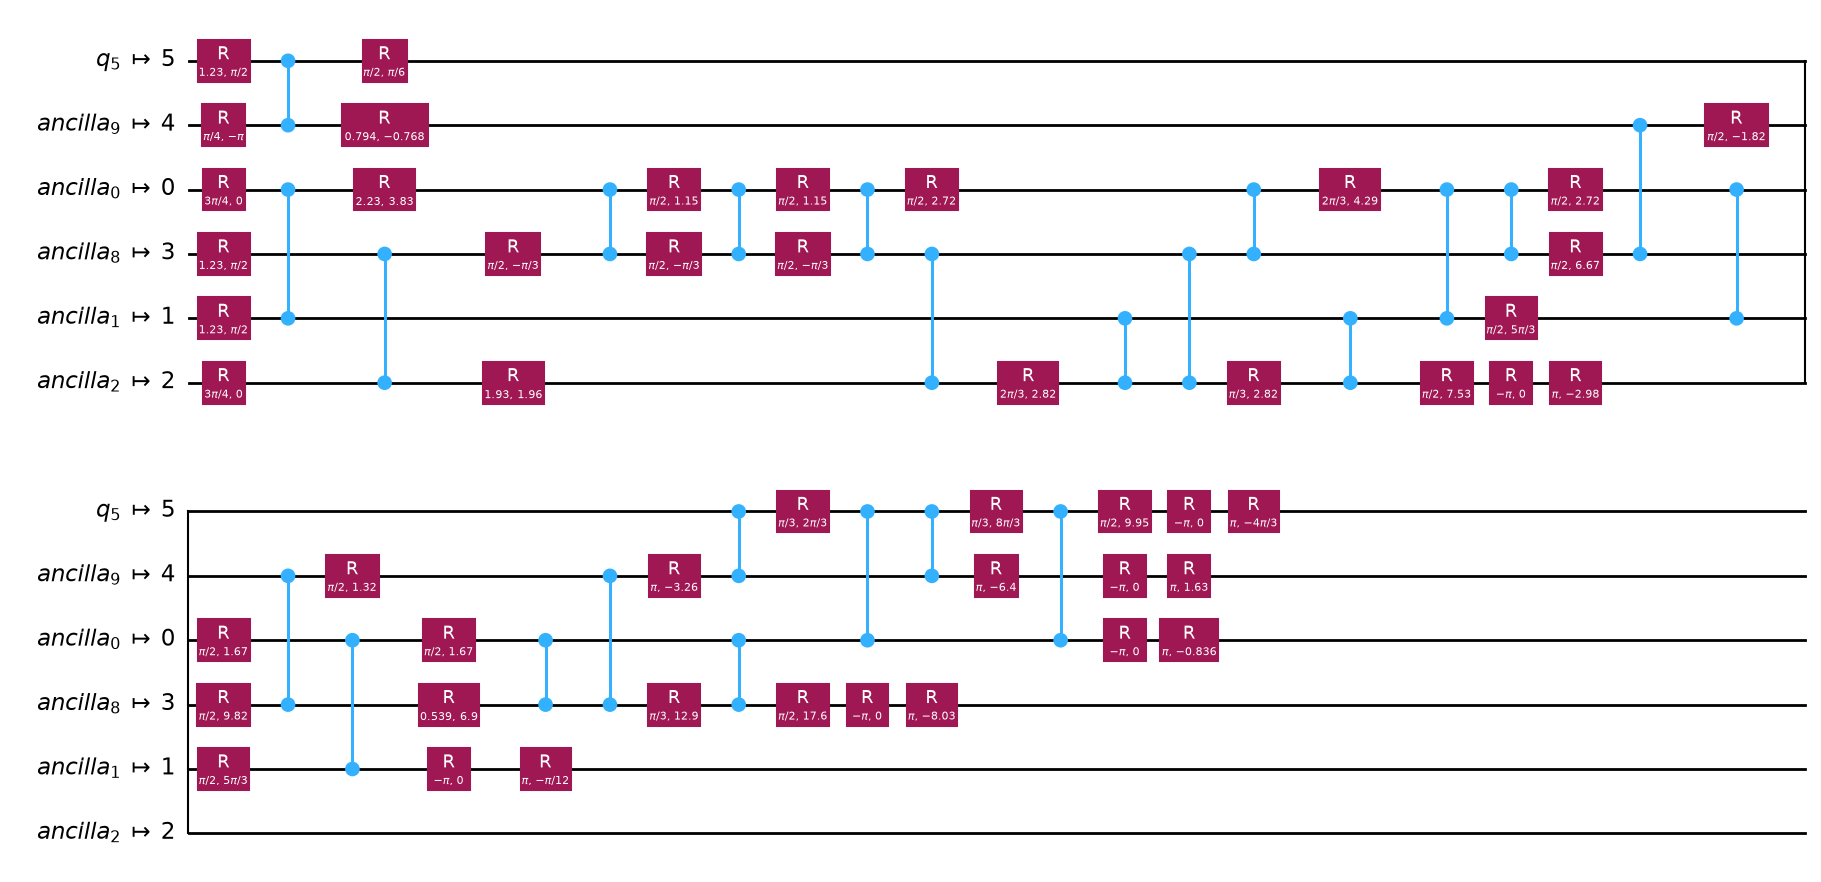

In [8]:
qcsuptrans.draw("mpl")

In [9]:
qcsuptrans.depth()

33

In [10]:
def fold_cz_preserve_layout(qc: QuantumCircuit, n: int = 3) -> QuantumCircuit:
      if n < 1:
          raise ValueError("n musi byc >= 1")
      if n % 2 == 0:
          raise ValueError("Do ZNE uzyj nieparzystego n: 1, 3, 5, ...")

      out = qc.copy()
      old_data = list(out.data)
      out.data.clear()

      for inst in old_data:
          op = inst.operation
          qargs = inst.qubits
          cargs = inst.clbits

          if op.name.lower() == "cz":
              for _ in range(n):
                  out.append(op.copy(), qargs, cargs)
          else:
              out.append(op.copy(), qargs, cargs)

      out.name = f"{qc.name}_czfold{n}"
      return out

In [11]:
layout = qcsuptrans.layout.final_index_layout(filter_ancillas=True)
qutrit_qubits = ((layout[0], layout[1]), (layout[2], layout[3]), (layout[4], layout[5]))

sampler_circuits, metadata = build_sampler_circuits_for_candidate(candidate="ghz3", state_circuit=qcsuptrans, E=Esup, qutrit_qubits=qutrit_qubits)
isa_sampler_qc = [transpile_to_IQM(qc, backend=backend_garnet, optimization_level=3, seed_transpiler=9) for qc in sampler_circuits]

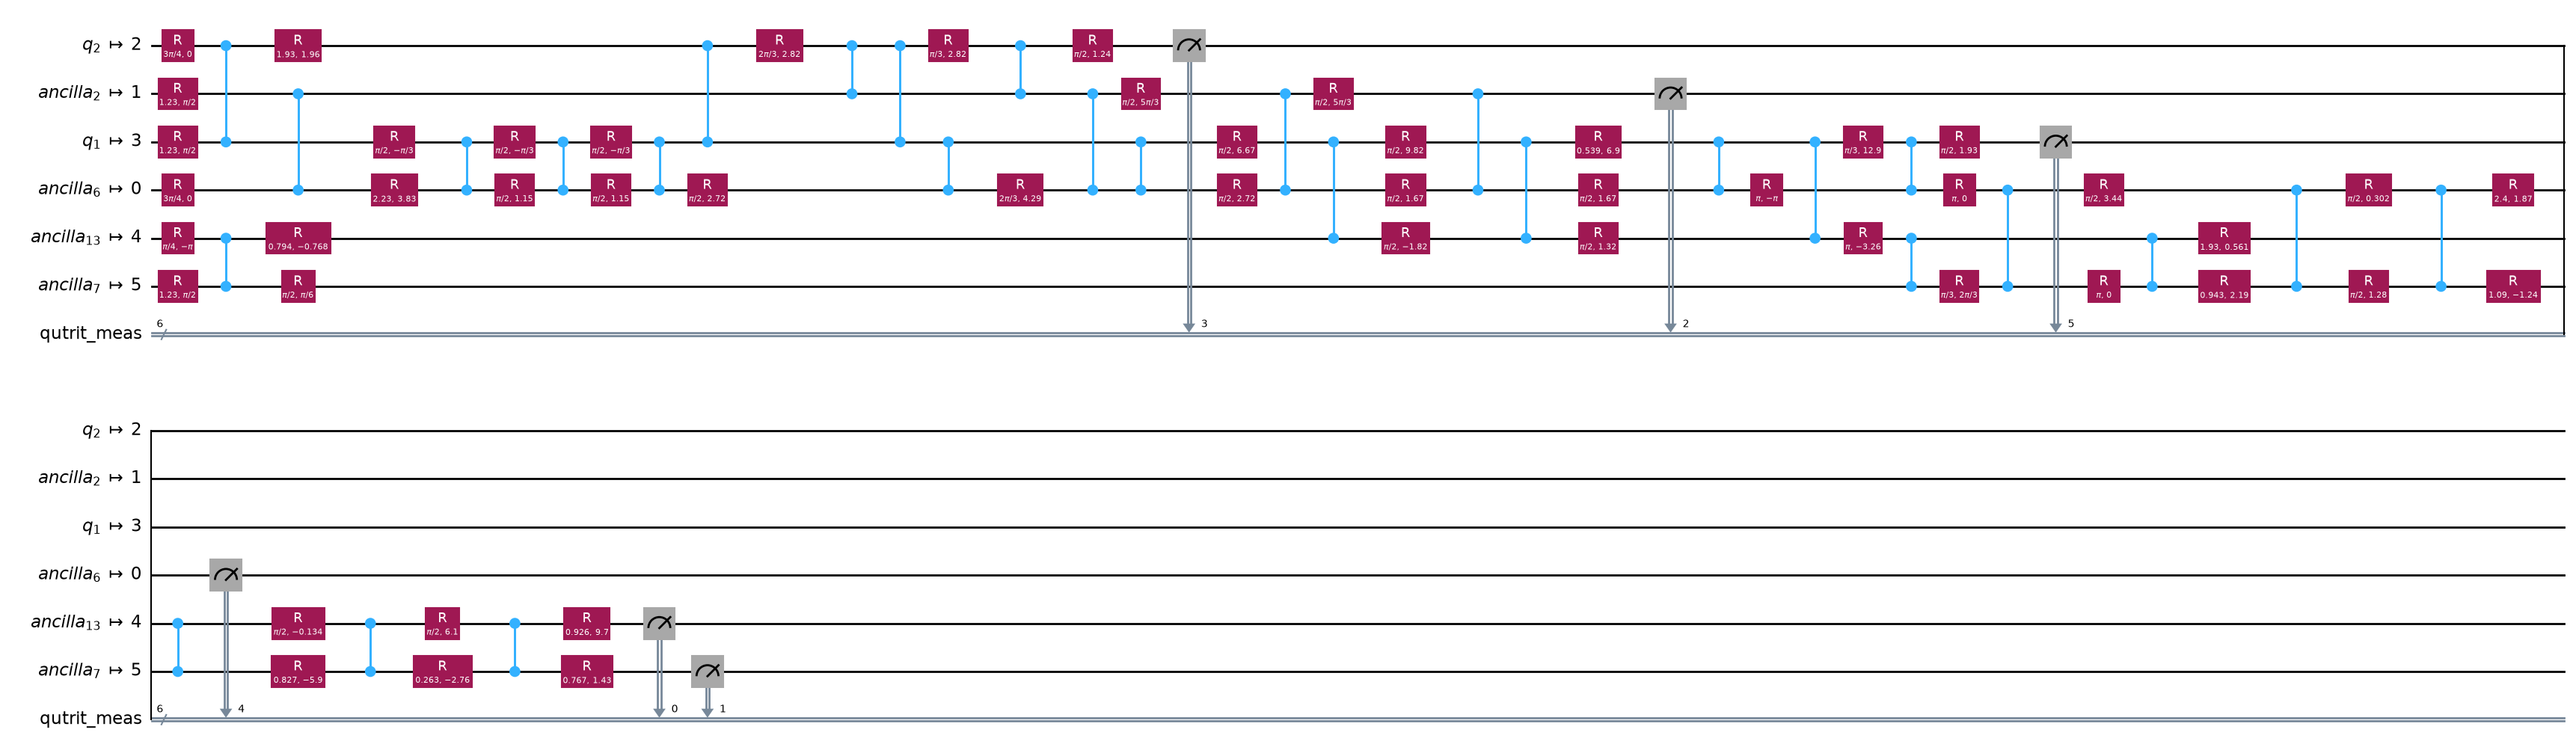

In [12]:
isa_sampler_qc[0].draw("mpl", idle_wires=False, fold=50)

In [13]:
isa_sampler_qc[0].depth()

41

In [14]:
isa_sampler_qc_1 = isa_sampler_qc
isa_sampler_qc_3 = [fold_cz_preserve_layout(qc, n=3) for qc in isa_sampler_qc]
isa_sampler_qc_5 = [fold_cz_preserve_layout(qc, n=5) for qc in isa_sampler_qc]

In [15]:
counts_by_setting, run_info = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())
counts_by_setting3, run_info3 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_3, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())
counts_by_setting5, run_info5 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_5, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())

In [16]:
bell_value = compute_bell_value_from_counts(counts_by_setting, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value3 = compute_bell_value_from_counts(counts_by_setting3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value5 = compute_bell_value_from_counts(counts_by_setting5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

bell_value, bell_value3, bell_value5

((6.003126389113446-9.485467966641181e-15j),
 (6.001238148942104-9.305056725139593e-15j),
 (5.985408726811233-9.360567876370851e-15j))

In [17]:
metadata["terms"]

[{'coeff': (0.5685790213016291+0.10025582212028974j),
  'settings': ('A0', 'B0', 'C0'),
  'powers': (1, 1, 1),
  'source': 'ghz3:0',
  'graph_power': 1},
 {'coeff': (0.568579021301629+0.10025582212028965j),
  'settings': ('A1', 'B0', 'C0'),
  'powers': (1, 1, 1),
  'source': 'ghz3:1',
  'graph_power': 1},
 {'coeff': (0.5685790213016287+0.10025582212028959j),
  'settings': ('A2', 'B0', 'C0'),
  'powers': (1, 1, 1),
  'source': 'ghz3:2',
  'graph_power': 1},
 {'coeff': (-0.18555679974213954+0.2211379827229797j),
  'settings': ('A0', 'B1', 'C0'),
  'powers': (1, 1, 1),
  'source': 'ghz3:3',
  'graph_power': 1},
 {'coeff': (0.2842895106508144+0.05012791106014476j),
  'settings': ('A1', 'B1', 'C0'),
  'powers': (1, 1, 1),
  'source': 'ghz3:4',
  'graph_power': 1},
 {'coeff': (-0.09873271090867483-0.2712658937831244j),
  'settings': ('A2', 'B1', 'C0'),
  'powers': (1, 1, 1),
  'source': 'ghz3:5',
  'graph_power': 1},
 {'coeff': (0.5685790213016291+0.10025582212028962j),
  'settings': ('A0', 

GHZ DD DEFAULT

In [18]:
# counts_by_setting_garnet, run_info_garnet = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_default})


In [19]:
# bell_value = compute_bell_value_from_counts(counts_by_setting_garnet, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [20]:
# bell_value

GHZ DD XY4

In [21]:
# counts_by_setting_garnet, run_info_garnet = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy4})
# bell_value_xy4 = compute_bell_value_from_counts(counts_by_setting_garnet, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
# bell_value_xy4

GHZ DD XY8

In [22]:
counts_by_setting_garnet_xy8, run_info_garnet_xy8 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy8})

In [23]:
bell_value_xy8 = compute_bell_value_from_counts(counts_by_setting_garnet_xy8, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [24]:
bell_value_xy8

(3.205084397798014-4.7878367936959876e-15j)

In [25]:
counts_by_setting_garnet3_xy8, run_info_garnet3_xy8 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_3, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy8})

Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

In [26]:
bell_value3_xy8 = compute_bell_value_from_counts(counts_by_setting_garnet3_xy8, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [27]:
bell_value3_xy8

(1.5243638596222988-2.0539125955565396e-15j)

In [28]:
counts_by_setting_garnet5_xy8, run_info_garnet5_xy8 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_5, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_xy8})

In [29]:
bell_value5_xy8 = compute_bell_value_from_counts(counts_by_setting_garnet5_xy8, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [30]:
bell_value5_xy8

(0.6583246606227184-6.87817858224804e-16j)

ZNE with DD XY8 without measurement miti

In [31]:
scale_factors = np.array([1.0, 3.0, 5.0])
bell_values = np.array([bell_value_xy8.real, bell_value3_xy8.real, bell_value5_xy8.real], dtype=float)

coeff = np.polyfit(scale_factors, bell_values, deg=1)
zne_linear = np.polyval(coeff, 0.0)

In [32]:
zne_linear

np.float64(3.7059941088958177)

MEAS miti

In [33]:
import mthree

In [34]:
mapping = mthree.utils.final_measurement_mapping(isa_sampler_qc[0])

In [35]:
mapping

{0: 12, 1: 13, 2: 3, 3: 2, 4: 8, 5: 7}

In [36]:
measured_physical_qubits = sorted(set(mapping.values()))
measured_physical_qubits

[2, 3, 7, 8, 12, 13]

In [37]:
from qiskit.circuit import QuantumCircuit
import numpy as np

def build_readout_calibration_matrices(
    backend,
    physical_qubits,
    shots=10_000
):
    """
    Zwraca listę macierzy kalibracyjnych M3.
    Dla kubitów, których nie kalibrujemy, pozostaje None.
    """
    matrices = [None] * backend.num_qubits

    for q in physical_qubits:
        # Przygotowanie |0> i pomiar kubitu q
        cal_0 = QuantumCircuit(backend.num_qubits, 1)
        cal_0.measure(q, 0)

        # Przygotowanie |1> i pomiar kubitu q
        cal_1 = QuantumCircuit(backend.num_qubits, 1)
        cal_1.x(q)
        cal_1.measure(q, 0)

        counts_0, counts_1 = backend.run(
            [cal_0, cal_1],
            shots=shots
        ).result().get_counts()

        # P(odczytano 1 | przygotowano 0)
        p10 = counts_0.get("1", 0) / shots

        # P(odczytano 0 | przygotowano 1)
        p01 = counts_1.get("0", 0) / shots

        # Kolumny: stan przygotowany |0>, |1>
        # Wiersze: stan odczytany  |0>, |1>
        matrices[q] = np.array(
            [
                [1 - p10, p01],
                [p10, 1 - p01]
            ],
            dtype=np.float32
        )

        print(f"Qubit {q}:")
        print(matrices[q])

    return matrices

In [39]:
calibration_matrix = [
    np.array([
        [0.9944, 0.0811],
        [0.0056, 0.9189]
    ]),
    np.array([
        [0.9965, 0.0117],
        [0.0035, 0.9883]
    ]),
    np.array([
        [0.9962, 0.0247],
        [0.0038, 0.9753]
    ]),
    np.array([
        [0.991,  0.0204],
        [0.009,  0.9796]
    ])
]

In [43]:
measured_physical_qubits

[2, 3, 7, 8, 12, 13]

In [42]:
calibration_matrix

[array([[0.9944, 0.0811],
        [0.0056, 0.9189]]),
 array([[0.9965, 0.0117],
        [0.0035, 0.9883]]),
 array([[0.9962, 0.0247],
        [0.0038, 0.9753]]),
 array([[0.991 , 0.0204],
        [0.009 , 0.9796]])]

In [55]:
calibration_matrix = build_readout_calibration_matrices(backend_garnet, measured_physical_qubits, shots=10000)

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Qubit 2:
[[0.9945 0.092 ]
 [0.0055 0.908 ]]
Qubit 3:
[[0.9933 0.0134]
 [0.0067 0.9866]]


Progress in queue:   0%|          | 0/8 [00:00<?, ?it/s]

Qubit 7:
[[0.9967 0.0364]
 [0.0033 0.9636]]
Qubit 8:
[[0.9912 0.0147]
 [0.0088 0.9853]]
Qubit 12:
[[0.9906 0.0179]
 [0.0094 0.9821]]


Progress in queue:   0%|          | 0/14 [00:00<?, ?it/s]

Qubit 13:
[[0.9884 0.0407]
 [0.0116 0.9593]]


In [57]:
mit = mthree.M3Mitigation()

mit.cals_from_matrices(calibration_matrix)

def apply_mitigation(counts_by_setting, mit, mapping):
    quasi = []

    for res in list(counts_by_setting.values()):
        quasi.append(mit.apply_correction(res, mapping, return_mitigation_overhead=True))

    quasi_miti = {}

    for i, setting in zip(quasi, list(counts_by_setting.keys())):
        quasi_temp = {}
        for key in i.keys():
            quasi_temp[key] = int(i[key]*1024*20)
        quasi_miti[setting] = quasi_temp

    return quasi_miti

In [58]:
counts_by_setting_garnet_miti = apply_mitigation(counts_by_setting_garnet_xy8, mit, mapping)
counts_by_setting_garnet_miti3 = apply_mitigation(counts_by_setting_garnet3_xy8, mit, mapping)
counts_by_setting_garnet_miti5 = apply_mitigation(counts_by_setting_garnet5_xy8, mit, mapping)

In [59]:
bell_value_miti = compute_bell_value_from_counts(counts_by_setting_garnet_miti, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value_miti3 = compute_bell_value_from_counts(counts_by_setting_garnet_miti3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value_miti5 = compute_bell_value_from_counts(counts_by_setting_garnet_miti5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [60]:
scale_factors = np.array([1.0, 3.0, 5.0])
bell_values = np.array([bell_value_miti.real, bell_value_miti3.real, bell_value_miti5.real], dtype=float)

coeff = np.polyfit(scale_factors, bell_values, deg=1)
zne_linear = np.polyval(coeff, 0.0)

In [ ]:
zne_linear

np.float64(4.982405530441956)

In [61]:
zne_linear

np.float64(4.285114225251905)

In [ ]:
6 * math.cos(math.pi / 9)

5.638155724715451